In [1]:
import boolean
import networkx
import random
import os
import pandas as pd
import subprocess
import csv
import re
import sys
import shutil

from bn import BN, random_boolean_function, generate_random_bn

from data_generation import *
from bnfinder_runner import *
from graph_utils import *
from comparison_utils import *

# from bnf_process import *

# Part I

### Zadanie 1 (Olek)
Konstruowanie sieci o różnych rozmiarach

Obiekt klasy `BN` konstruuje się podając listę zmiennych i funckji sformułowanych w postaci zrozumiałej dla obiektu klasy [`BooleanAlgebra()`](https://github.com/bastikr/boolean.py/blob/8a443837e68dc027004294fb17fe1857cf783410/boolean/boolean.py#L100) z modułu `boolean `, czyli Disjunctive Normal Form

In [2]:
random.seed(2)

# List of different networks (BN objects)
bns = [generate_random_bn(n) for n in [5, 10, 16]]

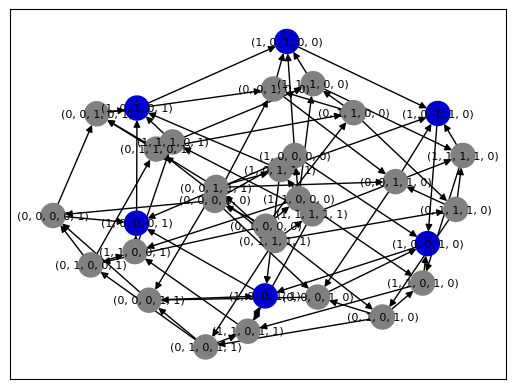

In [3]:
# Drawing STS graph example

bns[0].draw_state_transition_system(bns[0])

### Zadanie 2

Tworzenie datasetów o róznych właściwościach i zapisywanie ich w formacie odpowiednim dla BNFinder.

In [4]:
random.seed(0)

# Config
nums_of_traj = [1, 3, 8]
nums_of_steps = [10, 50, 100]
frequencies = [1, 3, 5]
ofat = ofat_combinations([nums_of_steps, nums_of_traj, frequencies])

origin_bn = datasets_for_gridsearch(bns, "./input_for_bnfinder", ofat)


### Zadanie 3

In [5]:
# Config
"""python2_path = "C:/Python27/bnfinder_py2/Scripts/python.exe"
bnfinder_path = "C:/Python27/bnfinder_py2/Scripts/bnf"

# Olek
python2_path = '/home/olek/miniconda3/envs/bnfinder/bin/python2'
bnfinder_path = '/home/olek/miniconda3/envs/bnfinder/bin/bnf'
"""
#Aga
python2_path = 'C:/Users/agnie/miniconda3/envs/SAD2/python.exe'
bnfinder_path = 'C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf'

In [6]:
score = "MDL"
run_bnfinder_and_collect('./input_for_bnfinder', f'./output_bnf_{score}', python2_path, bnfinder_path, score, 'total_scores')

Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_for_bnfinder\bn_0_m_asynch_t_1_s_50_f_3.txt -s MDL -n ./output_bnf_MDL\bn_0_m_asynch_t_1_s_50_f_3.sif -v
Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_for_bnfinder\bn_0_m_asynch_t_3_s_100_f_3.txt -s MDL -n ./output_bnf_MDL\bn_0_m_asynch_t_3_s_100_f_3.sif -v
Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_for_bnfinder\bn_0_m_asynch_t_3_s_10_f_3.txt -s MDL -n ./output_bnf_MDL\bn_0_m_asynch_t_3_s_10_f_3.sif -v
Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_for_bnfinder\bn_0_m_asynch_t_3_s_50_f_1.txt -s MDL -n ./output_bnf_MDL\bn_0_m_asynch_t_3_s_50_f_1.sif -v
Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e .

In [7]:
score = "BDE"
run_bnfinder_and_collect('./input_for_bnfinder', f'./output_bnf_{score}', python2_path, bnfinder_path, score, 'total_scores')

Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_for_bnfinder\bn_0_m_asynch_t_1_s_50_f_3.txt -s BDE -n ./output_bnf_BDE\bn_0_m_asynch_t_1_s_50_f_3.sif -v
Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_for_bnfinder\bn_0_m_asynch_t_3_s_100_f_3.txt -s BDE -n ./output_bnf_BDE\bn_0_m_asynch_t_3_s_100_f_3.sif -v
Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_for_bnfinder\bn_0_m_asynch_t_3_s_10_f_3.txt -s BDE -n ./output_bnf_BDE\bn_0_m_asynch_t_3_s_10_f_3.sif -v
Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_for_bnfinder\bn_0_m_asynch_t_3_s_50_f_1.txt -s BDE -n ./output_bnf_BDE\bn_0_m_asynch_t_3_s_50_f_1.sif -v
Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e .

### Zadanie 4

In [8]:
df_metrics_BDE = compare_results_multiple(origin_bn, r"./output_bnf_BDE")
df_metrics_MDL = compare_results_multiple(origin_bn, r"./output_bnf_MDL")

In [9]:
df_metrics_BDE.columns = pd.MultiIndex.from_product([['BDE'], df_metrics_BDE.columns])

df_metrics_MDL.columns = pd.MultiIndex.from_product([['MDL'], df_metrics_MDL.columns])

df_metrics_merged = pd.concat([df_metrics_BDE, df_metrics_MDL], axis=1)
df_metrics_merged.to_csv('bnf_metrics_comparison.csv')
df_metrics_merged.head()

BDE                                    MDL  \
                            SHD Jaccard Precision Recall        F1 SHD   
Dataset                                                                  
bn_0_m_asynch_t_3_s_100_f_3   3     0.5       0.5    1.0  0.666667   3   
bn_0_m_synch_t_3_s_50_f_3     3     0.0       0.0    0.0  0.000000   3   
bn_0_m_asynch_t_3_s_50_f_3    3     0.0       0.0    0.0  0.000000   3   
bn_0_m_asynch_t_8_s_50_f_3    3     0.5       0.5    1.0  0.666667   4   
bn_0_m_synch_t_3_s_100_f_3    3     0.5       0.5    1.0  0.666667   4   

                                                                  
                              Jaccard Precision Recall        F1  
Dataset                                                           
bn_0_m_asynch_t_3_s_100_f_3  0.500000  0.500000    1.0  0.666667  
bn_0_m_synch_t_3_s_50_f_3    0.500000  0.500000    1.0  0.666667  
bn_0_m_asynch_t_3_s_50_f_3   0.500000  0.500000    1.0  0.666667  
bn_0_m_asynch_t_8_s_50_f_3   0.428571  0.428571    1.0  0.600000  
bn_0_m_synch_t_3_s_100_f_3   0.428571  0.428571    1.0  0.600000

# Part II

In [10]:
random.seed(0)

model_bn = load_bnet_to_BN('model.bnet')

dataset_for_model(model_bn, mode='syn', num_steps=30, num_traj=10, freq=1, output_dir='./input_model', filename='model_data.txt')

score = 'MDL'
run_bnfinder_and_collect('./input_model', f'./output_model', python2_path, bnfinder_path, score, 'total_scores')

Executing: C:/Users/agnie/miniconda3/envs/SAD2/python.exe C:/Users/agnie/miniconda3/envs/SAD2/Scripts/bnf -e ./input_model\model_data.txt -s MDL -n ./output_model\model_data.sif -v


In [11]:
compare_results_single(model_bn, r"./output_model", 'model_data')

{'SHD': 54,
 'Jaccard': 0.325,
 'Precision': 0.65,
 'Recall': 0.3939393939393939,
 'F1': 0.49056603773584906}